# Grade Prediction using Machine Learning

## Project Objective

The objective of this project is to build a machine learning regression model that predicts a student's final grade based on academic and performance-related features.

The trained model will later be saved and integrated into a Flask web application to generate predictions dynamically.

In [1]:
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset

The student performance dataset was loaded into a Pandas DataFrame. This dataset contains academic, personal, and environmental factors that may influence a student's final exam score.

In [2]:
df = pd.read_csv("../dataset/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.shape

(6607, 20)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

### Observation

The dataset contains **6,607 records** and **20 features**, including both numerical and categorical variables.

Most features have complete data; however, **Teacher_Quality**, **Parental_Education_Level**, and **Distance_from_Home** contain missing values. These missing values must be handled during data preprocessing before training the machine learning model.

The target variable, **Exam_Score**, is numerical, making this dataset suitable for a regression problem.

## 4. Missing Values Analysis

The dataset was checked for missing values to identify incomplete records before data preprocessing. Missing values must be handled because machine learning algorithms cannot directly work with incomplete data.

In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## 5. Handle Missing Values

The missing values in the categorical features were replaced using **Mode Imputation**. Since these features contain text-based categories, the most frequently occurring value (mode) was used to fill the missing entries while preserving the dataset.

In [8]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0]
)

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

df.isnull().sum()


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

### Observation

The missing values were successfully handled using **Mode Imputation**. After preprocessing, all features contain complete data with no missing values, making the dataset suitable for further analysis and machine learning model training.

## 6. Duplicate Values Analysis

The dataset was checked for duplicate records to ensure data quality. Duplicate entries can introduce bias during model training and negatively affect the performance of machine learning models.

In [9]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset. This confirms that each row represents a unique student record, and no duplicate entries need to be removed before model training.

## 7. Statistical Summary

The statistical summary was generated to understand the distribution of numerical features, including their average values, spread, and range. This helps identify the overall characteristics of the dataset before model training.

In [10]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Observation

The statistical summary provides an overview of the numerical features, including their average values, minimum and maximum values, and overall distribution.

The summary indicates that the numerical features have reasonable ranges and will help in understanding student performance before applying machine learning models.

## 8. Target Variable Analysis

The distribution of the target variable (**Exam_Score**) was analyzed to understand how student scores are distributed across the dataset. This helps identify whether the target values are balanced, skewed, or contain unusual patterns before training the regression model.

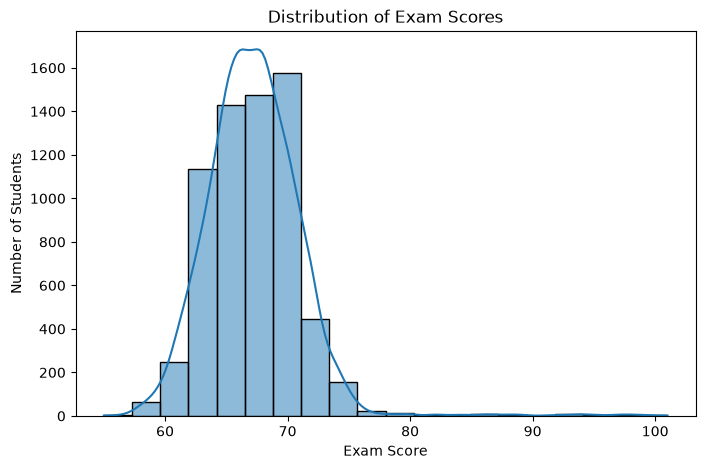

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Exam_Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

### Observation

The distribution of **Exam_Score** is approximately bell-shaped, with most students scoring between **63 and 71 marks**. The highest concentration of students is around **67–69 marks**, indicating that this is the most common performance range.

A slight right-skew is observed due to a small number of students achieving exceptionally high scores (above 80). Overall, the target variable is reasonably distributed and suitable for building a regression model.

## 9. Explore Categorical Features

The categorical features were explored to identify their unique categories before applying encoding. Machine learning algorithms require numerical input, so categorical values must be converted into numerical representations during preprocessing.

In [13]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


Parental_Involvement
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Access_to_Resources
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Extracurricular_Activities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Motivation_Level
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Internet_Access
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Family_Income
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Teacher_Quality
<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

School_Type
<StringArray>
['Public', 'Private']
Length: 2, dtype: str

Peer_Influence
<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

Learning_Disabilities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Parental_Education_Level
<StringArray>
['High School', 'College', 'Postgraduate']
Length: 3, dtype: str

Distance_from_Home
<StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dtype: str

Gender
<StringArray>
['Male', 

### Observation

The categorical features include both **binary** categories (such as Yes/No and Male/Female) and **ordinal** categories (such as Low/Medium/High).

Since several features have a natural order, manual mapping will be used instead of applying Label Encoding to every column. This preserves the logical relationship between the categories and provides more meaningful numerical representations for the regression model.

In [14]:
mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "No": 0,
    "Yes": 1,
    "Male": 1,
    "Female": 0,
    "Public": 0,
    "Private": 1,
    "Near": 0,
    "Moderate": 1,
    "Far": 2,
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
    "High School": 0,
    "College": 1,
    "Postgraduate": 2
}

In [22]:
df = df.replace(mapping)

In [23]:
df = df.infer_objects(copy=False)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int64
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int64
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  School_Type                 6607 non-null   int64
 13  Peer_Influence              6607 non-null   int64
 14  Physical_Activity  

### Observation

All categorical features were successfully converted into numerical values using manual mapping. After applying `infer_objects()`, every feature was stored as a numeric data type (`int64`), making the dataset fully compatible with machine learning algorithms.

## 11. Feature Selection

The dataset was divided into **input features (X)** and the **target variable (y)**. The input features will be used to train the regression model, while the target variable (**Exam_Score**) represents the value to be predicted.

In [25]:
X = df.drop("Exam_Score", axis=1)

y = df["Exam_Score"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (6607, 19)
Target Shape : (6607,)
